In [43]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
import warnings
import scipy.stats as stats
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from datetime import datetime
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch
from sklearn.metrics import silhouette_score

In [44]:

warnings.simplefilter(action='ignore', category=FutureWarning)


In [45]:
df = pd.read_csv("balanced_data_frame.csv")

In [46]:
df.shape

(34350, 14)

In [47]:
df.columns

Index(['user_type', 'created_at', 'pushed_at', 'updated_at',
       'open_issues_count', 'watchers_count', 'is_disabled', 'is_archieved',
       'user_name', 'state', 'contributions_count', 'language',
       'language_count', 'name'],
      dtype='object')

In [48]:
users_data = df[df['user_type'] == 'User']
orgs_data = df[df['user_type'] == 'Organization']

users_data = resample(users_data, replace=False, n_samples=len(orgs_data), random_state=123)

df = pd.concat([users_data, orgs_data])

In [49]:
users_data['created_at'] = pd.to_datetime(users_data['created_at'])
users_data['created_year'] = users_data['created_at'].dt.year
users_data['created_month'] = users_data['created_at'].dt.month
orgs_data['created_at'] = pd.to_datetime(orgs_data['created_at'])
orgs_data['created_year'] = orgs_data['created_at'].dt.year
orgs_data['created_month'] = orgs_data['created_at'].dt.month

<ipython-input-49-1c66574e6818>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orgs_data['created_at'] = pd.to_datetime(orgs_data['created_at'])
<ipython-input-49-1c66574e6818>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orgs_data['created_year'] = orgs_data['created_at'].dt.year
<ipython-input-49-1c66574e6818>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: ht

## Popular Languages among users and Organizations

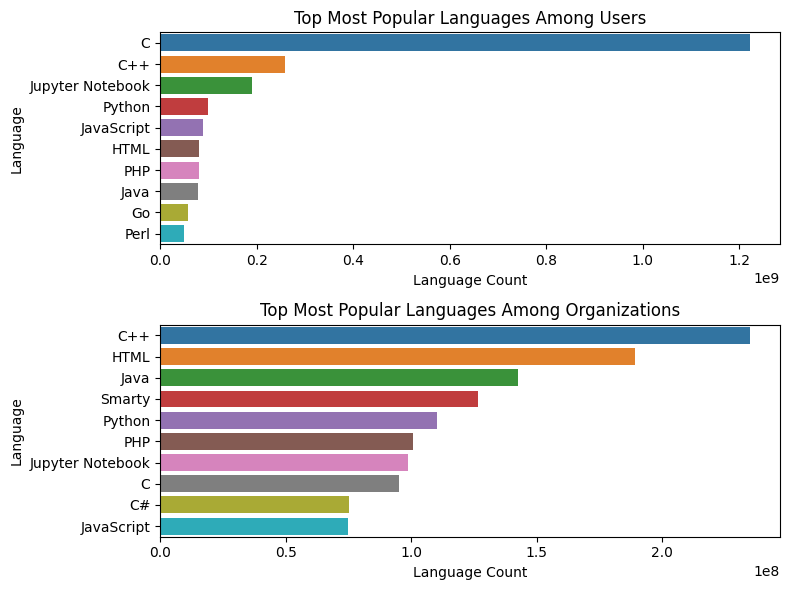

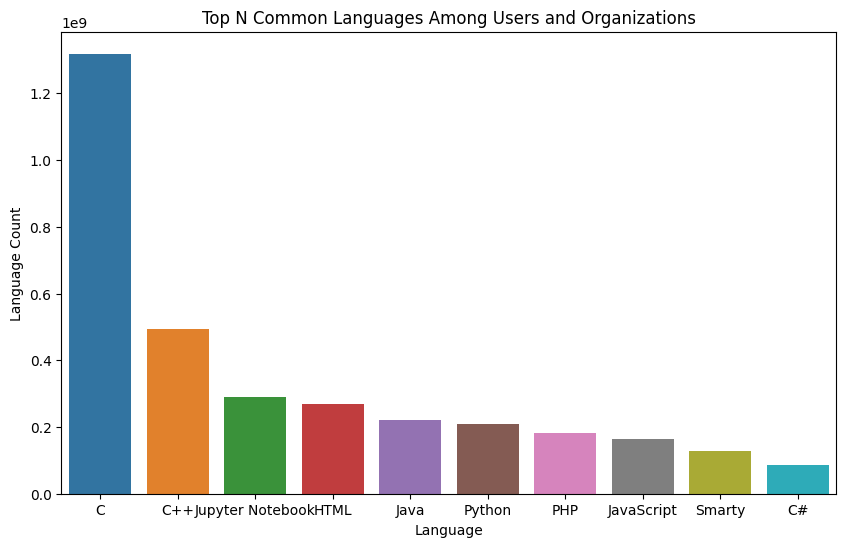

In [50]:

users_total_language_count = users_data.groupby('language')['language_count'].sum()
users_top_n_languages = users_total_language_count.sort_values(ascending=False)


orgs_total_language_count = orgs_data.groupby('language')['language_count'].sum()
orgs_top_n_languages = orgs_total_language_count.sort_values(ascending=False)
orgs_top_n_languages = orgs_top_n_languages.reset_index()
users_top_n_languages = users_top_n_languages.reset_index()


fig, axes = plt.subplots(2, 1, figsize=(8, 6))

sns.barplot(ax=axes[0], x='language_count', y='language', data=users_top_n_languages[0:10], ci=None)
axes[0].set_xlabel('Language Count')
axes[0].set_ylabel('Language')
axes[0].set_title('Top Most Popular Languages Among Users')

sns.barplot(ax=axes[1], x='language_count', y='language', data=orgs_top_n_languages[0:10], ci=None)
axes[1].set_xlabel('Language Count')
axes[1].set_ylabel('Language')
axes[1].set_title('Top Most Popular Languages Among Organizations')

plt.tight_layout()

plt.show()


merged_df = pd.concat([users_top_n_languages, orgs_top_n_languages], ignore_index=True)
language_counts = merged_df.groupby('language')['language_count'].sum().reset_index()

top_n_common_languages = language_counts.sort_values(by='language_count', ascending=False).head(10)
top_n_common_languages = top_n_common_languages.sort_values(by='language_count', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='language', y='language_count', data=top_n_common_languages, ci=None)

plt.xlabel('Language')
plt.ylabel('Language Count')
plt.title('Top N Common Languages Among Users and Organizations')
plt.show()



## Top N common languages usages over time

<ipython-input-51-fc5375f37959>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_series_data_df.drop_duplicates(inplace=True)


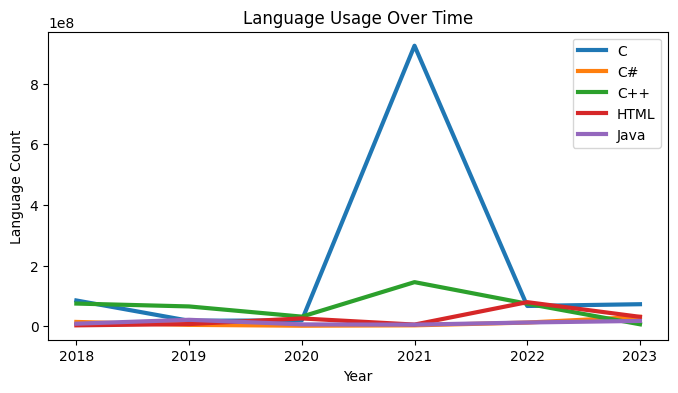

In [51]:

users_year_lang_lang_ct_df = users_data[['created_year', 'language', 'language_count']]
orgs_year_lang_lang_ct_df = orgs_data[['created_year', 'language', 'language_count']]
merged_users_orgs_year_lang_lang_ct_df = pd.concat([users_year_lang_lang_ct_df, orgs_year_lang_lang_ct_df])
time_series_data_df = merged_users_orgs_year_lang_lang_ct_df[merged_users_orgs_year_lang_lang_ct_df['language'].isin(top_n_common_languages['language'])]
time_series_data_df.drop_duplicates(inplace=True)

pivot_df = time_series_data_df.groupby(['created_year', 'language'])['language_count'].sum()

filtered_data = pivot_df.loc[(pivot_df.index.get_level_values('created_year').isin([2018,2019, 2020, 2021, 2022,2023]))]

pivot_for_plotting = filtered_data.unstack(level='language')
pivot_for_plotting.index = pivot_for_plotting.index.astype(int)

plt.figure(figsize=(8,4))
for language in pivot_for_plotting.columns[0:5]:
    plt.plot(pivot_for_plotting.index, pivot_for_plotting[language], label=language, linewidth=3.0)

plt.xticks([2018,2019, 2020, 2021, 2022,2023])
plt.xlabel('Year')
plt.ylabel('Language Count')
plt.title('Language Usage Over Time')
plt.legend()
plt.show()

## Proportion of states by contribution category

In [52]:

lower_threshold = df['contributions_count'].quantile(0.25)
higher_threshold = df['contributions_count'].quantile(0.75)


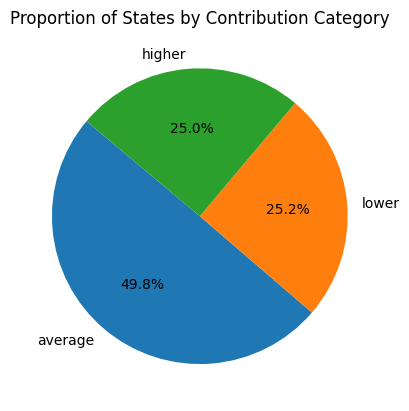

In [53]:
def categorize_contribution(count):
    if count <= lower_threshold:
        return 'lower'
    elif count >= higher_threshold:
        return 'higher'
    else:
        return 'average'

df['contribution_category'] = df['contributions_count'].apply(categorize_contribution)
grouped_states = df.groupby('contribution_category')['state'].apply(list)
category_counts = df['contribution_category'].value_counts()

category_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title('Proportion of States by Contribution Category')
plt.ylabel('')
plt.show()


## Contribution patterns over time based on contribution category

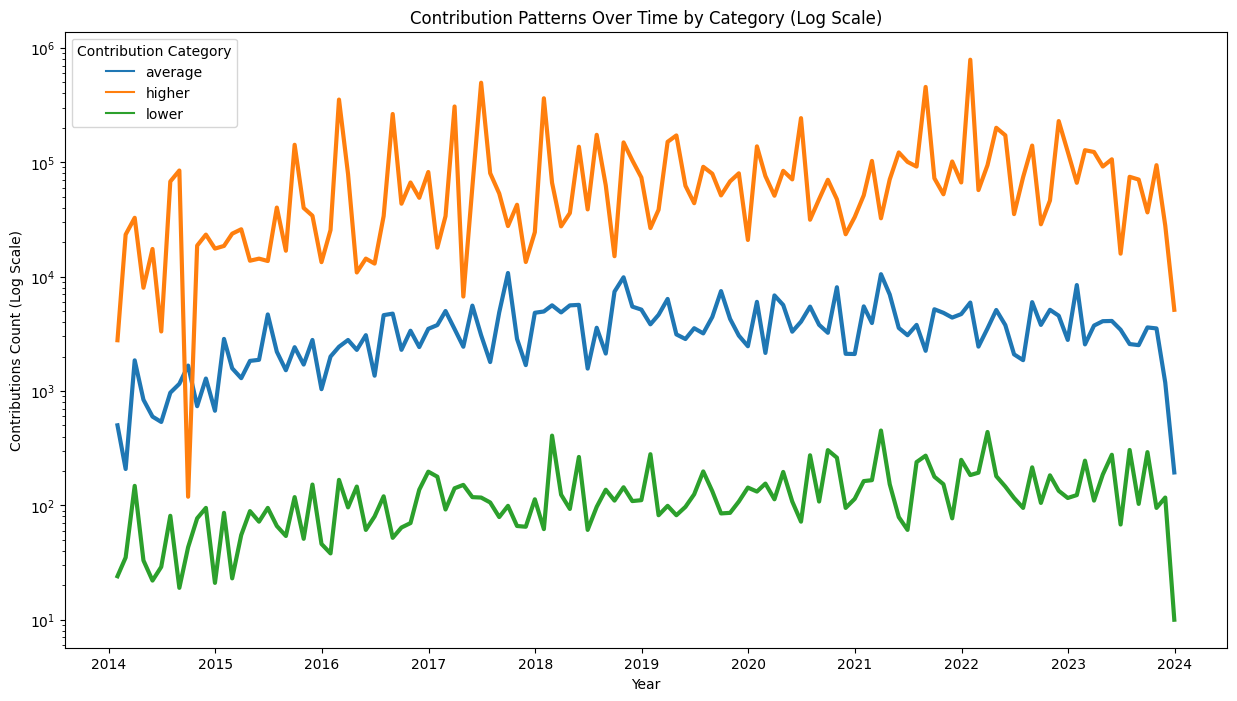

In [54]:
df['created_at'] = pd.to_datetime(df['created_at'])
df_filtered = df[df['created_at'].dt.year >= 2014]
df_resampled = df_filtered.set_index('created_at').groupby('contribution_category').resample('M')['contributions_count'].sum().reset_index()
plt.figure(figsize=(15, 8))
sns.lineplot(data=df_resampled, x='created_at', y='contributions_count', hue='contribution_category', linewidth=3.0)
plt.yscale('log')
plt.title('Contribution Patterns Over Time by Category (Log Scale)')
plt.xlabel('Year')
plt.ylabel('Contributions Count (Log Scale)')
plt.legend(title='Contribution Category')
plt.show()


## User Behavior

### How many repositories does each user have?

In [55]:
user_behaviour_df = users_data.groupby("user_name")['name'].size().reset_index()

In [56]:
user_behaviour_df.sort_values("name", ascending=False , inplace=True)

In [57]:
user_behaviour_df.head()

,user_name,name
1238,tgamblin,169
577,dbadapt,135
440,bendudson,98
37,BikeMaker,92
204,MarkBruns,83


### What is the average number of contributions per user??

In [58]:
avg_num_contributions_user = users_data.groupby("user_name")['contributions_count'].mean().reset_index()

In [59]:
avg_num_contributions_user.head()

,user_name,contributions_count
0,403-Fruit,230.583333
1,4x7y,56.312500
2,A0vanc01,65.000000
3,ADariusC03,60.052632
4,Aalap4,2.000000


# Hypothesis Testing

## Hypothesis-1 Language Specificity in Contributions
Null Hypothesis: The average number of contributions per user is the same across different programming languages.

Alternative Hypothesis: Certain programming languages are associated with significantly higher average contributions per user than others


 This could indicate that users who work with these languages are either more active or work on more complex projects.

In [60]:


avg_contributions_users = users_data.groupby('language')['contributions_count'].mean()
avg_contributions_orgs = orgs_data.groupby('language')['contributions_count'].mean()

contributions_per_language_users = [users_data[users_data['language'] == lang]['contributions_count'] for lang in users_data['language'].unique()]
contributions_per_language_orgs = [orgs_data[orgs_data['language'] == lang]['contributions_count'] for lang in orgs_data['language'].unique()]

anova_result_users = f_oneway(*contributions_per_language_users)
anova_result_orgs = f_oneway(*contributions_per_language_orgs)

print("ANOVA Result for Users:", anova_result_users)
print("ANOVA Result for Organizations:", anova_result_orgs)


ANOVA Result for Users: F_onewayResult(statistic=1.4407140724355925, pvalue=3.208177338454263e-07)
ANOVA Result for Organizations: F_onewayResult(statistic=1.9214497540510453, pvalue=8.997288525751171e-11)


### Conclusion:The null hypothesis for an ANOVA test typically states that there are no differences in the group means—in this case, that the average number of contributions per user is the same across different programming languages. so, reject NULL Hypothesis based on the ANOVA Results

## Hypothesis-2 Temporal Activity Patterns in Repository Creation
Proposition: there are no significant differences in repository creation across different times of the year.

Alternative Hypothesis:
 For instance, there could be increased activity during certain months, possibly related to events like hackathons, academic cycles, or industry trends



In [61]:
filtered_orgs_data_gt_2014 = orgs_data[(orgs_data['created_year'] >= 2014) & (orgs_data['created_year'] <= 2023)]
filtered_users_data_gt_2014 = users_data[(users_data['created_year'] >= 2014) & (users_data['created_year'] <= 2023)]

In [62]:
users_monthly_counts = filtered_users_data_gt_2014.groupby(['created_year', 'created_month']).size()
orgs_monthly_counts = filtered_orgs_data_gt_2014.groupby(['created_year', 'created_month']).size()

In [63]:
from statsmodels.tsa.seasonal import seasonal_decompose
monthly_counts = users_data.groupby(['created_year', 'created_month']).size()

anova_result = stats.f_oneway(*[group.values for name, group in users_data.groupby('created_month')['contributions_count']])
print("ANOVA Result:", anova_result)



ANOVA Result: F_onewayResult(statistic=2.3631209746752946, pvalue=0.0065312325221585435)


In [64]:
from statsmodels.tsa.seasonal import seasonal_decompose
monthly_counts = orgs_data.groupby(['created_year', 'created_month']).size()

anova_result = stats.f_oneway(*[group.values for name, group in orgs_data.groupby('created_month')['contributions_count']])
print("ANOVA Result:", anova_result)



ANOVA Result: F_onewayResult(statistic=24.36959831970915, pvalue=1.1990817515660922e-50)


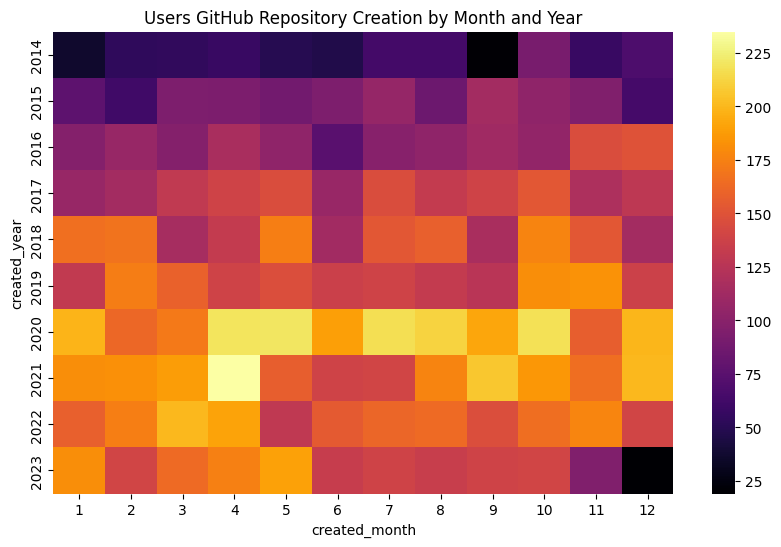

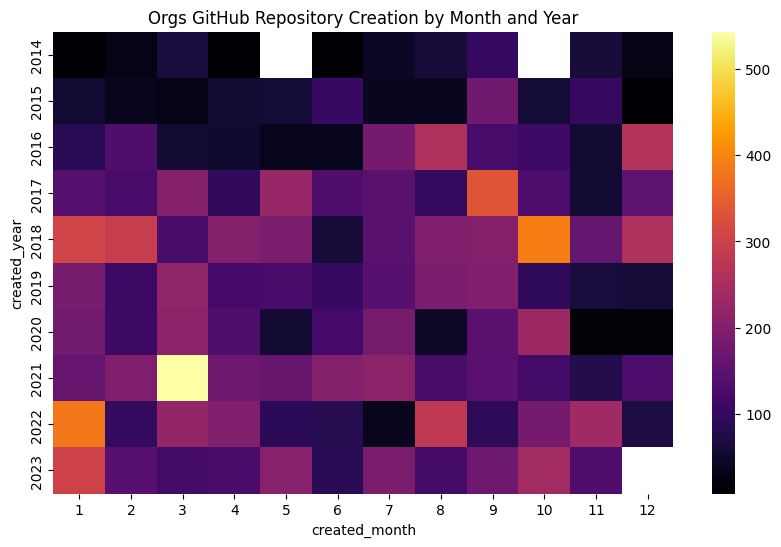

In [65]:
users_monthly_counts_df = users_monthly_counts.reset_index(name='counts')

users_heatmap_data = users_monthly_counts_df.pivot(index='created_year', columns='created_month', values='counts')

plt.figure(figsize=(10, 6))
sns.heatmap(users_heatmap_data, cmap='inferno')
plt.title('Users GitHub Repository Creation by Month and Year')
plt.show()


orgs_monthly_counts_df = orgs_monthly_counts.reset_index(name='counts')

users_heatmap_data = orgs_monthly_counts_df.pivot(index='created_year', columns='created_month', values='counts')

plt.figure(figsize=(10, 6))
sns.heatmap(users_heatmap_data, cmap='inferno')
plt.title('Orgs GitHub Repository Creation by Month and Year')
plt.show()


There seems to be a darker band across what appears to be the middle to the end of the year, particularly around months 11 (November), and 12 (December) for Organizations.

There seems to be a darker band across what appears to be the middle to the end of the year, particularly around months 11 (November), and 12 (December) for Organizations.

This could suggest that there is increased activity in creating new repositories towards the end of the year..

## Hypothesis-3:  Repository Activity and User Type Dynamics

Null Hypothesis: there is no significant difference in push or update frequencies between repositories owned by individual users and organizations.

Alternative Hypothesis: Repositories owned by organizations tend to have more frequent activity, possibly due to more resources or collaborative efforts within organizations.

t_Stat_push: -27.52399301723852
t_Stat_update -38.499728135081355
Average days since last push for organizations: 1234.6773799126638
Average days since last push for individual users: 1559.65903930131
P-value for push frequency comparison: 5.628665603217024e-165

Average days since last update for organizations: 926.4618922852984
Average days since last update for individual users: 1327.3570305676856
P-value for update frequency comparison: 0.0



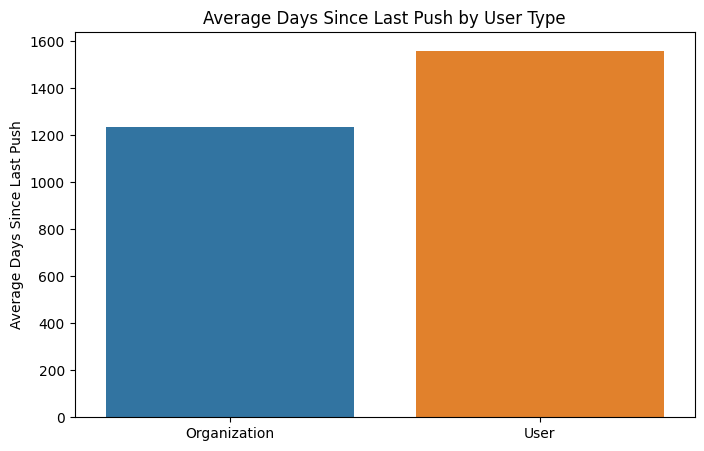

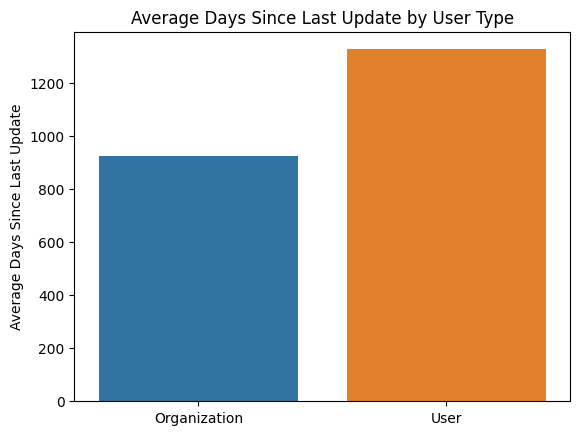

The difference in push frequency between organizations and individual users is statistically significant.
The difference in update frequency between organizations and individual users is statistically significant.


In [66]:

users_data['pushed_at'] = pd.to_datetime(users_data['pushed_at']).dt.tz_localize(None)
users_data['updated_at'] = pd.to_datetime(users_data['updated_at']).dt.tz_localize(None)

orgs_data['pushed_at'] = pd.to_datetime(orgs_data['pushed_at']).dt.tz_localize(None)
orgs_data['updated_at'] = pd.to_datetime(orgs_data['updated_at']).dt.tz_localize(None)

current_date = datetime.now()

users_data['days_since_last_push'] = (current_date - users_data['pushed_at']).dt.days
users_data['days_since_last_update'] = (current_date -users_data['updated_at']).dt.days
orgs_data['days_since_last_push'] = (current_date - orgs_data['pushed_at']).dt.days
orgs_data['days_since_last_update'] = (current_date -orgs_data['updated_at']).dt.days

org_push_avg = orgs_data['days_since_last_push'].mean()
user_push_avg = users_data['days_since_last_push'].mean()
org_update_avg = orgs_data['days_since_last_update'].mean()
user_update_avg = users_data['days_since_last_update'].mean()

df['pushed_at'] = pd.to_datetime(df['pushed_at']).dt.tz_localize(None)
df['updated_at'] = pd.to_datetime(df['updated_at']).dt.tz_localize(None)
df['days_since_last_push'] = (current_date - df['pushed_at']).dt.days
df['days_since_last_update'] = (current_date - df['updated_at']).dt.days


t_stat_push, p_val_push = ttest_ind(orgs_data['days_since_last_push'], users_data['days_since_last_push'], equal_var=False)
t_stat_update, p_val_update = ttest_ind(orgs_data['days_since_last_update'], users_data['days_since_last_update'], equal_var=False)

print(f"t_Stat_push: {t_stat_push}")
print(f"t_Stat_update {t_stat_update}")


print(f"Average days since last push for organizations: {org_push_avg}")
print(f"Average days since last push for individual users: {user_push_avg}")
print(f"P-value for push frequency comparison: {p_val_push}\n")

print(f"Average days since last update for organizations: {org_update_avg}")
print(f"Average days since last update for individual users: {user_update_avg}")
print(f"P-value for update frequency comparison: {p_val_update}\n")

plt.figure(figsize=(8, 5))

sns.barplot(x=['Organization', 'User'], y=[org_push_avg, user_push_avg])
plt.title('Average Days Since Last Push by User Type')
plt.ylabel('Average Days Since Last Push')
plt.show()

sns.barplot(x=['Organization', 'User'], y=[org_update_avg, user_update_avg])
plt.title('Average Days Since Last Update by User Type')
plt.ylabel('Average Days Since Last Update')
plt.show()


if p_val_push < 0.05:
    print("The difference in push frequency between organizations and individual users is statistically significant.")
else:
    print("No significant difference in push frequency between organizations and individual users.")

if p_val_update < 0.05:
    print("The difference in update frequency between organizations and individual users is statistically significant.")
else:
    print("No significant difference in update frequency between organizations and individual users.")


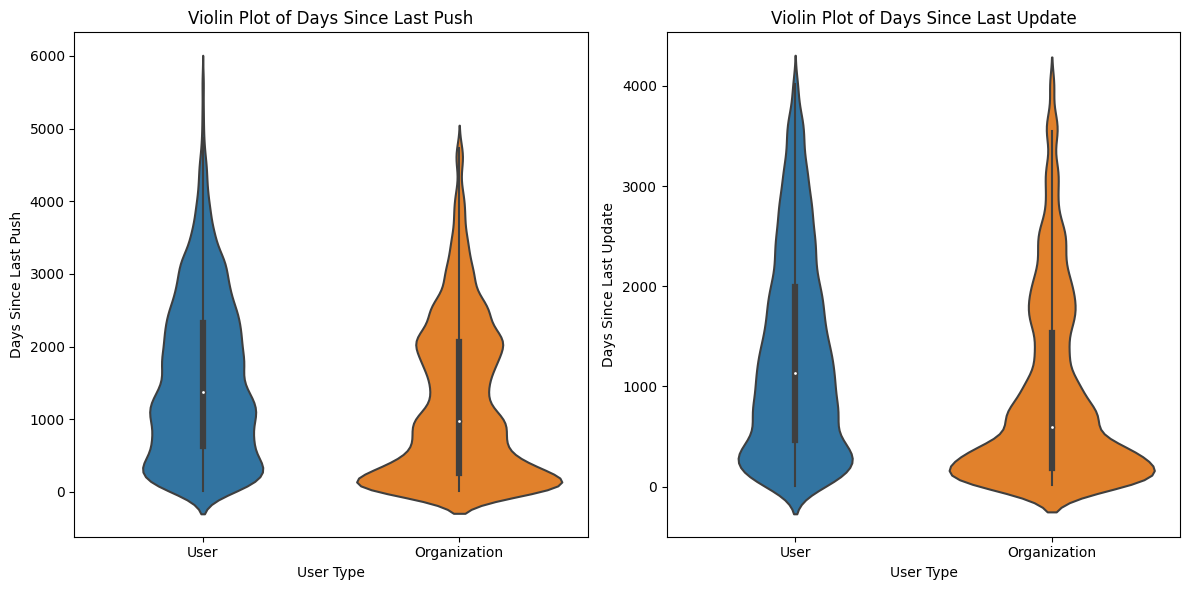

In [67]:

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.violinplot(x='user_type', y='days_since_last_push', data=df)
plt.title('Violin Plot of Days Since Last Push')
plt.xlabel('User Type')
plt.ylabel('Days Since Last Push')

plt.subplot(1, 2, 2)
sns.violinplot(x='user_type', y='days_since_last_update', data=df)
plt.title('Violin Plot of Days Since Last Update')
plt.xlabel('User Type')
plt.ylabel('Days Since Last Update')

plt.tight_layout()
plt.show()



###  Conclusion:
The shorter time since the last push and update for organizations suggests that they are more active in terms of repository maintenance and updates. This could be due to various factors like larger teams, more resources, or organizational policies that encourage regular updates and maintenance.


## Hypothesis-4:  Are certain languages more popular in certain states?
Null Hypothesis: Certain Languages are more popular in certain states

Alternative Hypothesis:  Certain languages are not popular in certain states




In [68]:
users_grouped_data = df.groupby(['state', 'language'])['language_count'].sum().reset_index()
sorted_data = users_grouped_data.sort_values(['state', 'language_count'], ascending=[True, False])

most_popular_language = sorted_data.drop_duplicates('state')
grouped_data = df.groupby('state').apply(lambda x: x.nlargest(1, 'language_count')).reset_index(drop=True)
common_languages = grouped_data.groupby('language')['state'].apply(list)
common_languages = common_languages.reset_index()

In [69]:
common_languages = common_languages[0:15]


In [70]:
from scipy.stats import chi2_contingency


num_repetitions = 100
sample_size = 1000

chi2_results = []
p_values = []

for _ in range(num_repetitions):

    sampled_data = users_data.sample(n=sample_size, replace=True)


    contingency_table_sampled = pd.crosstab(sampled_data['state'], sampled_data['language'])


    chi2_sampled, p_sampled, _, _ = chi2_contingency(contingency_table_sampled)

    chi2_results.append(chi2_sampled)
    p_values.append(p_sampled)

mean_chi2 = np.mean(chi2_results)
mean_p = np.mean(p_values)

print(f"Mean Chi-squared statistic over {num_repetitions} repetitions: {mean_chi2}")
print(f"Mean P-value over {num_repetitions} repetitions: {mean_p}")


alpha = 0.05
if mean_p < alpha:
    print("There is a statistically significant association between states and programming languages (based on repeated sampling).")
else:
    print("There is no statistically significant association between states and programming languages (based on repeated sampling).")


Mean Chi-squared statistic over 100 repetitions: 6300.021183936012
Mean P-value over 100 repetitions: 0.5848210925880365
There is no statistically significant association between states and programming languages (based on repeated sampling).


In [71]:
from scipy.stats import chi2_contingency


num_repetitions = 100
sample_size = 1000

chi2_results = []
p_values = []

for _ in range(num_repetitions):

    sampled_data = orgs_data.sample(n=sample_size, replace=True)


    contingency_table_sampled = pd.crosstab(sampled_data['state'], sampled_data['language'])


    chi2_sampled, p_sampled, _, _ = chi2_contingency(contingency_table_sampled)

    chi2_results.append(chi2_sampled)
    p_values.append(p_sampled)

mean_chi2 = np.mean(chi2_results)
mean_p = np.mean(p_values)

print(f"Mean Chi-squared statistic over {num_repetitions} repetitions: {mean_chi2}")
print(f"Mean P-value over {num_repetitions} repetitions: {mean_p}")


alpha = 0.05
if mean_p < alpha:
    print("There is a statistically significant association between states and programming languages (based on repeated sampling).")
else:
    print("There is no statistically significant association between states and programming languages (based on repeated sampling).")


Mean Chi-squared statistic over 100 repetitions: 4404.441954389897
Mean P-value over 100 repetitions: 5.287165818391628e-17
There is a statistically significant association between states and programming languages (based on repeated sampling).


In [72]:
language_total_counts = df.groupby('language')['language_count'].sum().reset_index()

top_languages = language_total_counts.nlargest(5, 'language_count')

for index, row in top_languages.iterrows():
    language = row['language']
    language_data = df[df['language'] == language]
    popular_states = language_data.nlargest(5, 'language_count')
    print(f"{language} is popular in the following states:")
    print(popular_states[['state', 'language_count']])
    print()

C is popular in the following states:
          state  language_count
8039   Illinois       829145435
14686  Illinois        71476825
11268  Colorado        61598748
6361     Oregon        59691265
9329    Indiana        49579122

C++ is popular in the following states:
            state  language_count
22337  California        57317175
16518       Idaho        48279597
2563     New York        43214248
16145  California        39273942
25543       Maine        37350709

Jupyter Notebook is popular in the following states:
          state  language_count
29126     Idaho        70324746
12765  Virginia        67773558
15409  Illinois        41799488
3439      Idaho        41126659
9906   Michigan        29604479

HTML is popular in the following states:
            state  language_count
27441    Illinois        42495009
27528    Illinois        27059391
9727      Arizona        26356862
21718  California        24220460
2197      Arizona        22076289

Java is popular in the following

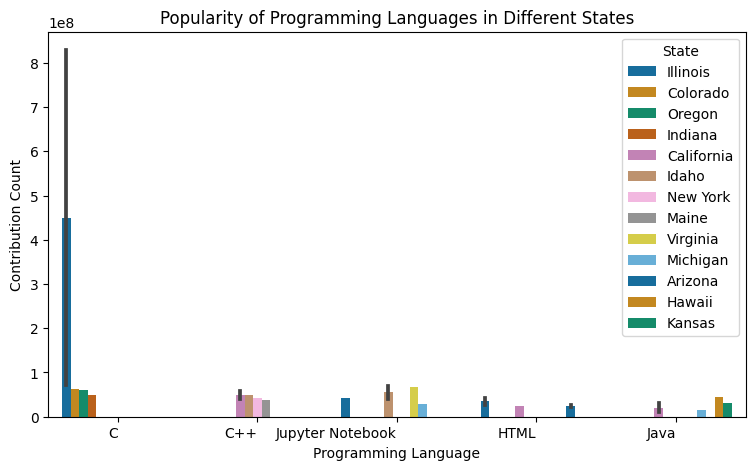

In [73]:

language_total_counts = df.groupby('language')['language_count'].sum().reset_index()

top_languages = language_total_counts.nlargest(5, 'language_count')

languages = []
states = []
counts = []

for index, row in top_languages.iterrows():
    language = row['language']
    language_data = df[df['language'] == language]
    popular_states = language_data.nlargest(5, 'language_count')

    for _, state_row in popular_states.iterrows():
        languages.append(language)
        states.append(state_row['state'])
        counts.append(state_row['language_count'])

visualization_data = pd.DataFrame({'Language': languages, 'State': states, 'Contribution Count': counts})

plt.figure(figsize=(9, 5))
sns.barplot(data=visualization_data, x='Language', y='Contribution Count', hue='State', palette='colorblind')
plt.title('Popularity of Programming Languages in Different States')
plt.xlabel('Programming Language')
plt.ylabel('Contribution Count')
plt.xticks( ha='right')
plt.legend(title='State')
plt.show()


### Conclusion:

  We can conclude that the languages are popular across certain states for individual users but not for the organizations

## Hypothesis-5: Relationship Between Contributor Engagement and Open Issue Counts
Null Hypothesis: Repositories with higher contributor engagement (measured by contributions count) tend to have lower open issue counts, suggesting more active maintenance.
Approach: Correlate the contributions count with open issues count across repositories to validate if more active contributors lead to fewer open issues.

In [74]:
from scipy.stats import pearsonr

users_contributions = users_data['contributions_count']
users_open_issues = users_data['open_issues_count']
orgs_contributions = orgs_data['contributions_count']
orgs_open_issues = orgs_data['open_issues_count']


users_corr, users_p_value = pearsonr(users_contributions, users_open_issues)
orgs_corr, orgs_p_value = pearsonr(orgs_contributions, orgs_open_issues)

print(f'Correlation coefficient for users: {users_corr}')
print(f'Correlation coefficient for orgs: {orgs_corr}')
print(f'p-value for users: {users_p_value}')
print(f'p-value for orgs: {orgs_p_value}')


Correlation coefficient for users: -0.0038206055710655485
Correlation coefficient for orgs: 0.06965141066037392
p-value for users: 0.6166042144527281
p-value for orgs: 6.332996986576189e-20


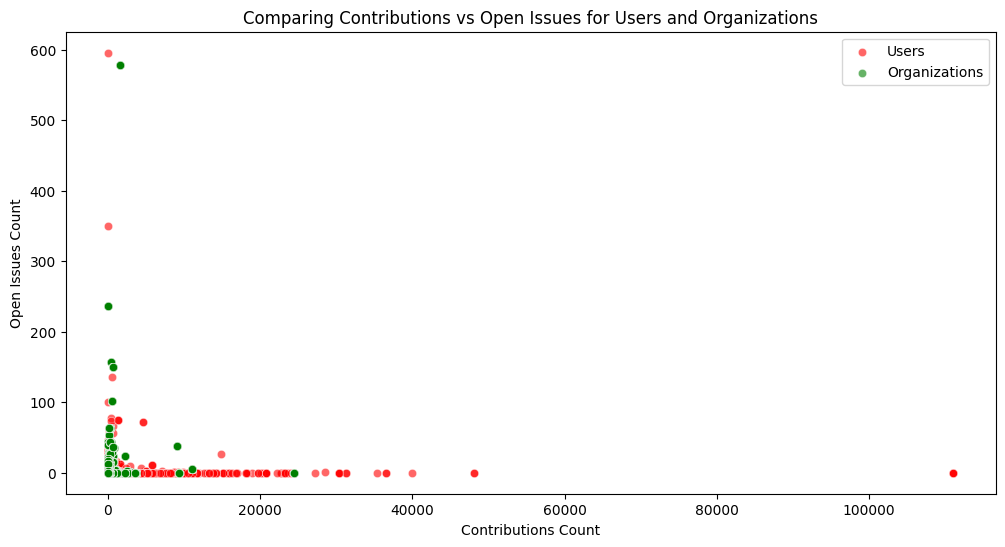

In [75]:
plt.figure(figsize=(12, 6))


sns.scatterplot(x=users_contributions, y=users_open_issues, label='Users', alpha=0.6, color="red")
sns.scatterplot(x=orgs_contributions, y=orgs_open_issues, label='Organizations', alpha=0.6, color='green')

plt.title('Comparing Contributions vs Open Issues for Users and Organizations')
plt.xlabel('Contributions Count')
plt.ylabel('Open Issues Count')
plt.legend()
plt.show()


### Conclusions: Reject the Hypotheses for orgs and accept for individuals

Based on these results, we can conclude the following:

We can accept the proposition that repositories with higher contributor engagement (measured by contributions count) tend to have lower open issue counts, but this relationship appears to be more suitable for users than for individuals.

## Hypothesis-6: Impact of Archival on Contribution Momentum


Proposition: The momentum of contributions (rate of change in contribution count) decreases significantly after a repository is archived


.
Investigation Approach: For repositories that have been archived, analyze the trend in contributions before and after the archival date to see if there is a marked decrease in the rate of contributions

In [76]:

from scipy.stats import ttest_ind


orgs_data['pushed_at'] = pd.to_datetime(orgs_data['pushed_at'])
orgs_data.sort_values(by='pushed_at', inplace=True)

users_data['pushed_at'] = pd.to_datetime(users_data['pushed_at'])
users_data.sort_values(by='pushed_at', inplace=True)

users_active_repos = users_data[users_data['is_archieved'] == False]
users_archived_repos = users_data[users_data['is_archieved'] == True]

orgs_active_repos = orgs_data[orgs_data['is_archieved'] == False]
orgs_archived_repos = orgs_data[orgs_data['is_archieved'] == True]

users_active_repos['month_year'] = users_active_repos.loc[:,'pushed_at'].dt.to_period('M')
users_archived_repos['month_year'] = users_archived_repos.loc[:,'pushed_at'].dt.to_period('M')


orgs_active_repos['month_year'] = orgs_active_repos.loc[:, 'pushed_at'].dt.to_period('M')
orgs_archived_repos['month_year'] = orgs_archived_repos.loc[:, 'pushed_at'].dt.to_period('M')

users_pushes_per_month_active = users_active_repos.groupby('month_year').size().mean()
users_pushes_per_month_archived = users_archived_repos.groupby('month_year').size().mean()


orgs_pushes_per_month_active = orgs_active_repos.groupby('month_year').size().mean()
orgs_pushes_per_month_archived = orgs_archived_repos.groupby('month_year').size().mean()

users_t_stat, users_p_value = ttest_ind(users_active_repos.groupby('month_year').size(), users_archived_repos.groupby('month_year').size(), equal_var=False)

orgs_t_stat, orgs_p_value = ttest_ind(orgs_active_repos.groupby('month_year').size(), orgs_archived_repos.groupby('month_year').size(), equal_var=False)


print(f"Users: Average number of pushes per month for active repositories: {users_pushes_per_month_active}")
print(f"Users: Average number of pushes per month for archived repositories: {users_pushes_per_month_archived}")
print("")
print(f"Orgs: Average number of pushes per month for active repositories: {orgs_pushes_per_month_active}")
print(f"Orgs: Average number of pushes per month for archived repositories: {orgs_pushes_per_month_archived}")
print("")
print(f"Users: P-value for difference in pushes per month: {users_p_value}\n")
print(f"Orgs: P-value for difference in pushes per month: {orgs_p_value}\n")
print("")

if orgs_p_value < 0.05 and users_p_value < 0.05:
    print("The difference in push frequency between active and archived repositories is statistically significant.")
else:
    print("No significant difference in push frequency between active and archived repositories.")



Users: Average number of pushes per month for active repositories: 94.41011235955057
Users: Average number of pushes per month for archived repositories: 3.217391304347826

Orgs: Average number of pushes per month for active repositories: 120.6953125
Orgs: Average number of pushes per month for archived repositories: 29.25423728813559

Users: P-value for difference in pushes per month: 2.8229240648722175e-37

Orgs: P-value for difference in pushes per month: 2.540962992074488e-11


The difference in push frequency between active and archived repositories is statistically significant.


<ipython-input-76-97cf6e68ab6a>:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  users_active_repos['month_year'] = users_active_repos.loc[:,'pushed_at'].dt.to_period('M')
<ipython-input-76-97cf6e68ab6a>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  users_archived_repos['month_year'] = users_archived_repos.loc[:,'pushed_at'].dt.to_period('M')
<ipython-input-76-97cf6e68ab6a>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

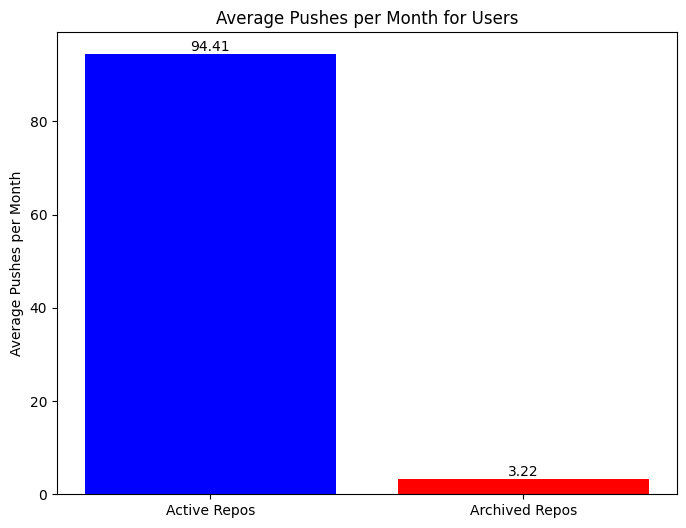

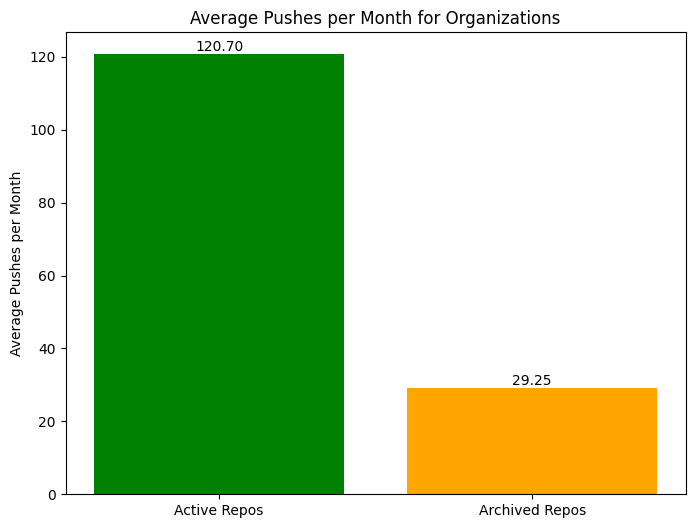

In [77]:

plt.figure(figsize=(8, 6))
plt.bar(['Active Repos', 'Archived Repos'], [users_pushes_per_month_active, users_pushes_per_month_archived], color=['blue', 'red'])
plt.title('Average Pushes per Month for Users')
plt.ylabel('Average Pushes per Month')
for i, val in enumerate([users_pushes_per_month_active, users_pushes_per_month_archived]):
    plt.text(i, val, f'{val:.2f}', ha='center', va='bottom')
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(['Active Repos', 'Archived Repos'], [orgs_pushes_per_month_active, orgs_pushes_per_month_archived], color=['green', 'orange'])
plt.title('Average Pushes per Month for Organizations')
plt.ylabel('Average Pushes per Month')
for i, val in enumerate([orgs_pushes_per_month_active, orgs_pushes_per_month_archived]):
    plt.text(i, val, f'{val:.2f}', ha='center', va='bottom')
plt.show()


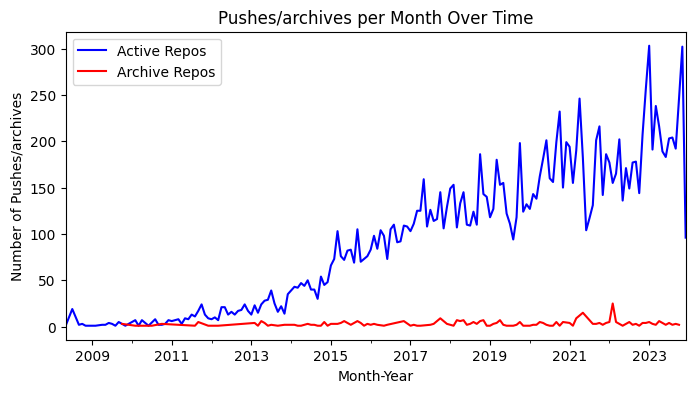

In [78]:

active_pushes = users_active_repos.groupby('month_year').size()
archive_count = users_archived_repos.groupby('month_year').size()
plt.figure(figsize=(8, 4))
active_pushes.plot(label='Active Repos', color='blue')
archive_count.plot(label='Archive Repos', color='red')
plt.title('Pushes/archives per Month Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Number of Pushes/archives')
plt.legend()
plt.show()


### Conclusion: Reject the Hypothesiss
The difference in push frequency between active and archived repositories is statistically significant.


## Hypothesis-7: How does number of repositories vary by state
Null Hypothesis (H0): The mean number of repositories is the same across all states.

Alternative Hypothesis (H1): The mean number of repositories is not the same across all states.

In [79]:

mean_repositories_per_state = df.groupby('state')['contributions_count'].mean()
std_dev = df.groupby('state')['contributions_count'].mean().std()


anova_result = stats.f_oneway(*[group['contributions_count'].values for name, group in df.groupby('state')])

alpha = 0.05
if anova_result.pvalue < alpha:
    print("There is a statistically significant difference in the mean number of repositories among states.")
else:
    print("There is no statistically significant difference in the mean number of repositories among states.")



There is a statistically significant difference in the mean number of repositories among states.


In [80]:
import statsmodels.stats.multicomp as multi

tukey_result = multi.pairwise_tukeyhsd(endog=df['contributions_count'], groups=df['state'], alpha=0.05)

tukey_df = pd.DataFrame(data=tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])

rejected_pairs = tukey_df[tukey_df['reject'] == True]


/usr/local/lib/python3.10/dist-packages/scipy/integrate/_quadpack_py.py:1233: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


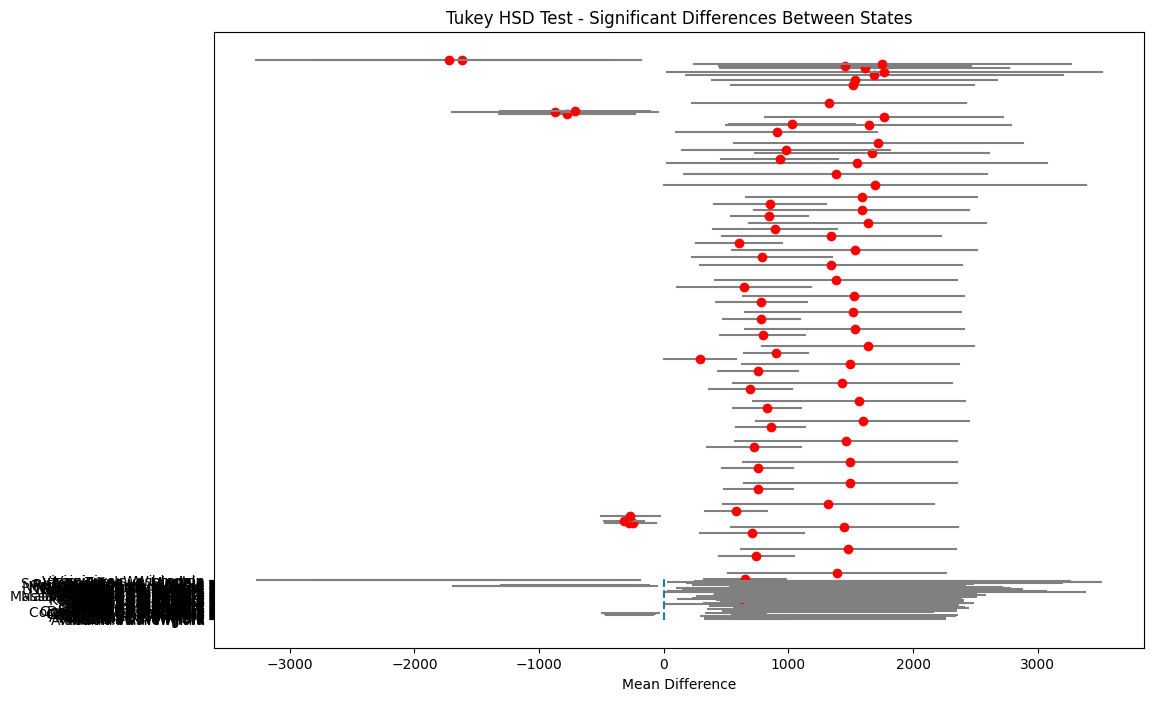

In [81]:
plt.figure(figsize=(12, 8))


for index, row in rejected_pairs.iterrows():
    plt.plot([row['lower'], row['upper']], [index, index], color='gray')
    plt.plot(row['meandiff'], index, 'ro')


plt.hlines(y=range(len(rejected_pairs)), xmin=rejected_pairs['lower'], xmax=rejected_pairs['upper'], color='gray')
plt.vlines(x=0, ymin=-1, ymax=len(rejected_pairs), linestyles='dashed')

plt.yticks(ticks=range(len(rejected_pairs)), labels=['{} vs. {}'.format(row['group1'], row['group2']) for index, row in rejected_pairs.iterrows()])
plt.xlabel('Mean Difference')
plt.title('Tukey HSD Test - Significant Differences Between States')


plt.show()


## Hypothesis-8: Geographical Distribution
Hypothesis: The geographical distribution of repository owners (users vs organizations) shows significant differences.

H0 (Null Hypothesis): The geographical distribution of repository owners is the same for users and organizations.

H1 (Alternative Hypothesis): The geographical distribution of repository owners is different for users and organizations

In [82]:
import pandas as pd
from scipy.stats import chi2_contingency
import numpy as np


sample_size = 1000


sampled_users_data = users_data.sample(n=sample_size, random_state=1)
sampled_orgs_data = orgs_data.sample(n=sample_size, random_state=1)


state_dist_sampled_users = sampled_users_data['state'].value_counts()
state_dist_sampled_orgs = sampled_orgs_data['state'].value_counts()

contingency_table_sampled = pd.DataFrame({
    'Users': state_dist_sampled_users,
    'Organizations': state_dist_sampled_orgs
}).fillna(0)

chi2_sampled, p_sampled, _, _ = chi2_contingency(contingency_table_sampled)

print(f"Chi-squared statistic (sampled data): {chi2_sampled}")
print(f"P-value (sampled data): {p_sampled}")

if p_sampled < 0.05:
    print("There is a statistically significant difference in the state distribution of users vs organizations (based on sampled data).")
else:
    print("There is no statistically significant difference in the state distribution of users vs organizations (based on sampled data).")


Chi-squared statistic (sampled data): 488.08688710017253
P-value (sampled data): 3.024415177380484e-76
There is a statistically significant difference in the state distribution of users vs organizations (based on sampled data).


In [83]:


num_repetitions = 100
sample_size = 1000

chi2_results = []
p_values = []

for i in range(num_repetitions):

    sampled_users_data = users_data.sample(n=sample_size, replace=True)
    sampled_orgs_data = orgs_data.sample(n=sample_size, replace=True)


    state_dist_sampled_users = sampled_users_data['state'].value_counts()
    state_dist_sampled_orgs = sampled_orgs_data['state'].value_counts()

    contingency_table_sampled = pd.DataFrame({
        'Users': state_dist_sampled_users,
        'Organizations': state_dist_sampled_orgs
    }).fillna(0)


    chi2_sampled, p_sampled, _, _ = chi2_contingency(contingency_table_sampled)


    chi2_results.append(chi2_sampled)
    p_values.append(p_sampled)

mean_chi2 = np.mean(chi2_results)
mean_p = np.mean(p_values)

print(f"Mean Chi-squared statistic over {num_repetitions} repetitions: {mean_chi2}")
print(f"Mean P-value over {num_repetitions} repetitions: {mean_p}")


Mean Chi-squared statistic over 100 repetitions: 485.38259027329224
Mean P-value over 100 repetitions: 2.766457783947797e-65


<Figure size 1200x600 with 0 Axes>

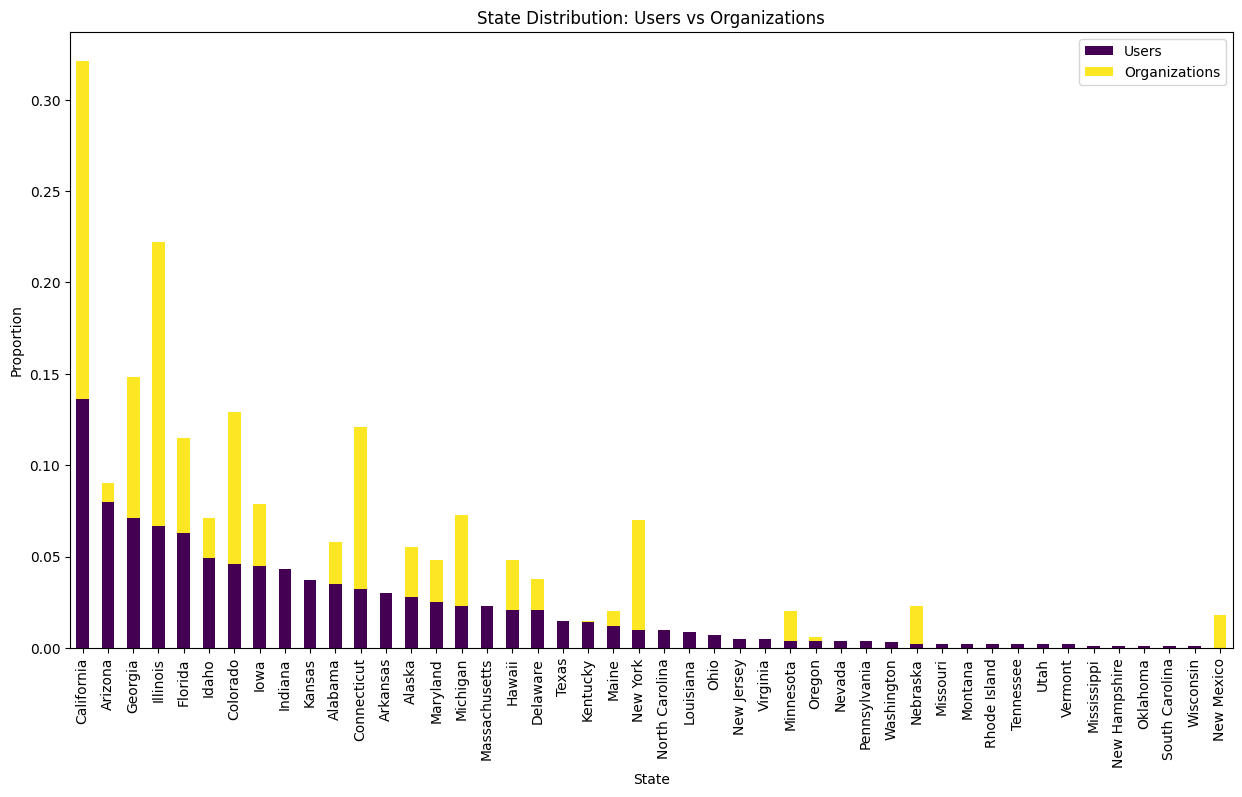

In [84]:

state_dist_users_normalized = state_dist_sampled_users / state_dist_sampled_users.sum()
state_dist_orgs_normalized = state_dist_sampled_orgs / state_dist_sampled_orgs.sum()

state_dist_df = pd.DataFrame({'Users': state_dist_users_normalized, 'Organizations': state_dist_orgs_normalized})

sorted_df = state_dist_df.sort_values(by=['Users', 'Organizations'], ascending=False)

plt.figure(figsize=(12, 6))
sorted_df.plot(kind='bar', stacked=True, colormap='viridis', figsize=(15, 8))
plt.title('State Distribution: Users vs Organizations')
plt.xlabel('State')
plt.ylabel('Proportion')
plt.xticks(rotation=90)
plt.show()


### Conclusion:
The geographical distribution of repository owners is different for users and organizations

# Clustering

## K-Means

In [85]:
df['user_type_encoded']=df['user_type'].apply(lambda x : 0 if x == "User" else 1)

In [86]:
kmeans = KMeans(n_clusters=2, random_state=123)


In [87]:
kmeans.fit(df[['user_type_encoded']])

KMeans(n_clusters=2, random_state=123)

In [88]:
cluster_labels = kmeans.labels_

In [89]:
df['user_type_clusters'] = cluster_labels

In [90]:
users_data = df[df['user_type_clusters'] == 0]
organizations_data = df[df['user_type_clusters'] == 1]


In [91]:
silhouette_avg = silhouette_score(df[['user_type_encoded']], kmeans.labels_)

In [92]:
print(silhouette_avg)

1.0


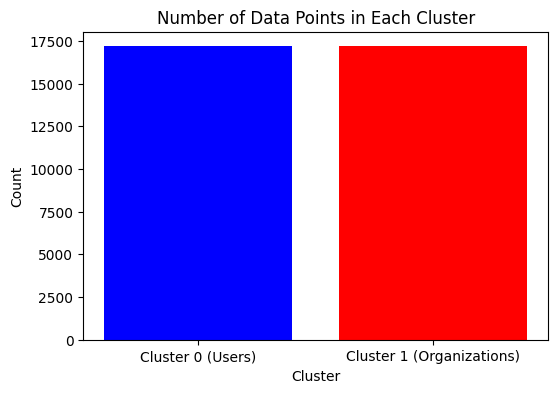

In [93]:

users_count = len(users_data)
organizations_count = len(organizations_data)

plt.figure(figsize=(6, 4))


labels = ['Cluster 0 (Users)', 'Cluster 1 (Organizations)']

counts = [users_count, organizations_count]


plt.bar(labels, counts, color=['blue', 'red'])
plt.title('Number of Data Points in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')



plt.show()

## DB SCAN Clustering

In [97]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [98]:
feature = 'user_type'

label_encoder = LabelEncoder()
df['user_type_encoded'] = label_encoder.fit_transform(df[feature])

dbscan = DBSCAN(eps=0.5, min_samples=5)


cluster_labels = dbscan.fit_predict(df[['user_type_encoded']])

df['user_type_encoded_cluster'] = cluster_labels



In [99]:
from sklearn.metrics import silhouette_score
import numpy as np

users_data = df[df['user_type_encoded_cluster'] == np.min(cluster_labels)]
organizations_data = df[df['user_type_encoded_cluster'] == np.max(cluster_labels)]


silhouette_avg = silhouette_score(df[['user_type_encoded']], cluster_labels)
print(f"Silhouette Score: {silhouette_avg:.2f}")




Silhouette Score: 1.00


## Hierarchical Clustering

In [95]:

agg_clustering = AgglomerativeClustering(n_clusters=2, linkage='ward', affinity='euclidean')
cluster_labels = agg_clustering.fit_predict(df[['user_type_encoded']])

df['user_type_encoded_hc'] = cluster_labels

users_data = df[df['user_type_encoded_hc'] == 0]
organizations_data = df[df['user_type_encoded_hc'] == 1]


In [96]:
silhouette_avg_hc = silhouette_score(df[['user_type_encoded']], cluster_labels)
silhouette_avg_hc

1.0

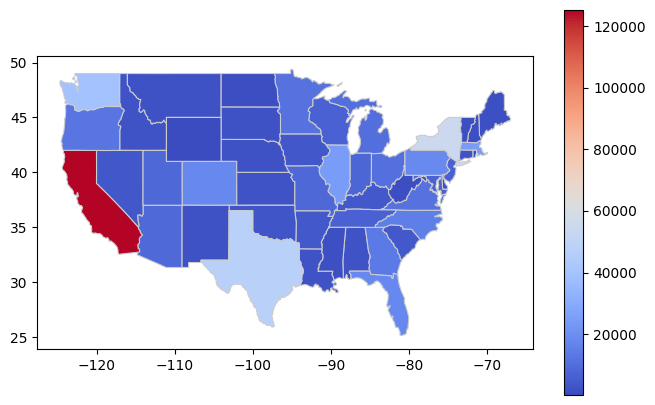

In [94]:

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

data = {
    'State': ['Alabama', 	'Connecticut', 	'Illinois', 	'Maine', 	'Mississippi', 	'New Hampshire', 	'North Dakota', 	'Rhode Island', 	'Utah', 	'Wisconsin', 	'California', 	'Kentucky', 	'Minnesota', 	'Nevada', 	'North Carolina', 	'Pennsylvania', 	'Texas', 	'West Virginia', 	'Arkansas', 	'Georgia', 	'Kansas', 	'Michigan', 	'Nebraska', 	'New York', 	'Oregon', 	'Tennessee', 	'Washington', 	'Arizona', 	'Florida', 	'Iowa', 	'Massachusetts', 	'Montana', 	'New Mexico', 	'Oklahoma', 	'South Dakota', 	'Virginia', 	'District of Columbia', 	'Delaware', 	'Indiana', 	'Maryland', 	'Missouri', 	'New Jersey', 	'Ohio', 	'South Carolina', 	'Vermont', 	'Wyoming', 	'Colorado', 	'Idaho', 	'Louisiana'],
    'Value': [2617, 	1932, 	24633, 	1264, 	1589, 	1530, 	730, 	762, 	8051, 	6182, 	125270, 	3722, 	10962, 	3232, 	15015, 	18518, 	47423, 	1068, 	3678, 	13566, 	2245, 	10177, 	1905, 	54889, 	12365, 	6499, 	39729, 	8751, 	17886, 	3424, 	24221, 	1712, 	1785, 	2818, 	1717, 	11153, 	8528, 	742, 	7603, 	6880, 	8323, 	6359, 	10558, 	3653, 	782, 	208, 	18218, 	2427, 	2593]
}
states_df = pd.DataFrame(data)

us_states = gpd.read_file('https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json')

merged = us_states.set_index('name').join(states_df.set_index('State'))


fig, ax = plt.subplots(figsize=(8, 5))
merged.plot(column='Value', cmap='coolwarm', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)
plt.show()
